<a href="https://colab.research.google.com/github/marinakamal1/undergrad_ml_assignments/blob/main/05_assignment_glm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

Marina Kamal

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use these models because many real outcomes are not well described by a plain linear relationship. A standard linear model assumes the prediction is just a weighted sum of the inputs, which works well for continuous outcomes but can be inappropriate for probabilities, classes, counts, or more complex patterns. General linear models and latent variable models let us model a linear combination of predictors first, and then transform it in a way that matches the type of outcome we care about. Activation functions do something similar in machine learning: they take a linear combination and pass it through a nonlinear transformation so the model can represent more flexible patterns. Their main advantage over ordinary linear models is that they can: handle outcomes that are binary or categorical, keep predictions in a meaningful range, like between 0 and 1 for probabilities, represent nonlinear relationships through transformations, while still often keeping a simple linear structure underneath. So the key idea is the model may still be linear in a hidden or latent score, but the final prediction is transformed to better fit the problem.

2. Binary and categorical cross entropy are effective because logistic regression is designed to predict probabilities, and cross entropy measures how well those predicted probabilities match the true labels. These loss functions heavily reward the model when it assigns high probability to the correct class, and they heavily penalize it when it is confidently wrong. That makes them especially useful for classification. They are also effective because they come directly from maximum likelihood estimation. In logistic regression, fitting the model with cross entropy is equivalent to choosing the coefficients that make the observed data most likely under the model. So cross entropy is not arbitrary; it is the natural loss function for probabilistic classification with logistic regression.

3. The statement that logistic regression is a linear model is true, but only in a specific sense. Logistic regression models the log-odds of the outcome as a linear combination of the predictors, meaning it is linear in terms of its coefficients and predictors at that level. However, the final predicted probability is obtained by applying a nonlinear transformation to this linear combination. Therefore, while it is technically a linear model in the latent space (log-odds), it is nonlinear in terms of the predicted probabilities.

4. False. Logistic regression is commonly used for classification. It predicts the probability that an observation belongs to a class, and then we can convert that probability into a class label using a threshold such as 0.5. So even though logistic regression outputs probabilities, it is absolutely a classification method. In fact, it is one of the most standard classification models.

5. Not directly. In ordinary linear regression, a coefficient tells you the change in the predicted outcome for a one-unit increase in the predictor, holding other variables fixed. In logistic regression, that is not how the coefficient works for the predicted probability. Instead, a coefficient gives the change in the log-odds for a one-unit increase in the feature, holding other variables fixed. Equivalently, if you exponentiate the coefficient, you get the multiplicative change in the odds. Because probability is a nonlinear transformation of the log-odds, the effect of a one-unit increase in a predictor on the predicted probability depends on where you already are. So the same coefficient can imply a different probability change for different observations.

6. False. Logistic regression is only nonlinear in the transformation from log-odds to probability, but it is still linear in the predictors. This means it cannot automatically capture complex nonlinear relationships or interactions. Feature engineering is still important to include those patterns explicitly

7. False. Logistic regression is more appropriate when the outcome is binary or categorical, but ordinary least squares is better for continuous outcomes. Each model is designed for different types of problems, so one is not universally better than the other.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("data.csv", sep=";")

cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df2 = df[cols].copy()

print("Shape:", df2.shape)
print("\nColumns:", df2.columns.tolist())

print("\nMissing values:")
print(df2.isna().sum())

df2["dropout"] = (df2["Target"] == "Dropout").astype(int)

print("\nTarget counts:")
print(df2["Target"].value_counts())

print("\nBinary dropout counts:")
print(df2["dropout"].value_counts())

Shape: (4424, 6)

Columns: ['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target']

Missing values:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

Target counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Binary dropout counts:
dropout
0    3003
1    1421
Name: count, dtype: int64


In [3]:
X = df2[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df2["dropout"]

logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

print("Intercept:")
print(logit.intercept_)

print("\nCoefficients:")
for name, coef in zip(X.columns, logit.coef_[0]):
    print(name, coef)

Intercept:
[0.48569266]

Coefficients:
Debtor 0.5306254196925666
Tuition fees up to date -2.55654243281313
Scholarship holder -1.227441522252298
Age at enrollment 0.04992541246433546


Students who are debtors and those with a higher age at enrollment are predicted to have a higher probability of dropping out, as both variables have positive coefficients (0.531 and 0.0499, respectively). This means that being a debtor or being older at enrollment increases the log-odds of dropout. In contrast, students who are up to date on tuition and those who are scholarship holders are predicted to have a lower probability of dropping out, since both variables have negative coefficients (-2.557 and -1.227, respectively). Among all predictors, being up to date on tuition has the largest magnitude coefficient, indicating it has the strongest association with reduced dropout risk. Therefore, being up to date on tuition appears to substantially reduce the probability of dropout.

   Age at enrollment  Tuition fees up to date  logit_prob
0                 20                        1    0.254958
1                 19                        0    0.807567
2                 19                        0    0.807567
3                 20                        1    0.254958
4                 45                        1    0.543836


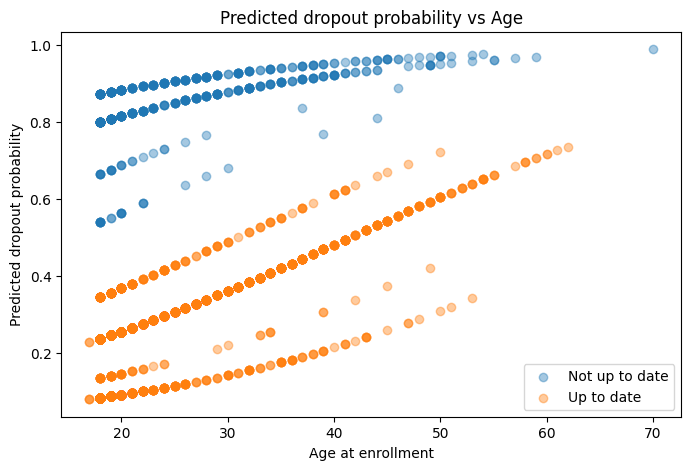


Average change in dropout probability (tuition up to date):
-0.5161819741831828

Effect by age (lowest values):
Age at enrollment
22   -0.537499
23   -0.535802
21   -0.535541
20   -0.532669
24   -0.531446
19   -0.529255
25   -0.527728
26   -0.527287
18   -0.525951
27   -0.524518
Name: delta_tuition, dtype: float64


In [4]:
df2["logit_prob"] = logit.predict_proba(X)[:, 1]

print(df2[["Age at enrollment", "Tuition fees up to date", "logit_prob"]].head())

plt.figure(figsize=(8,5))

for tuition_value, label in [(0, "Not up to date"), (1, "Up to date")]:
    subset = df2[df2["Tuition fees up to date"] == tuition_value]
    plt.scatter(subset["Age at enrollment"], subset["logit_prob"], alpha=0.4, label=label)

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted dropout probability vs Age")
plt.legend()
plt.show()

X0 = X.copy()
X1 = X.copy()

X0["Tuition fees up to date"] = 0
X1["Tuition fees up to date"] = 1

p0 = logit.predict_proba(X0)[:, 1]
p1 = logit.predict_proba(X1)[:, 1]

delta = p1 - p0

print("\nAverage change in dropout probability (tuition up to date):")
print(delta.mean())

age_effect = pd.DataFrame({
    "Age at enrollment": X["Age at enrollment"],
    "delta_tuition": delta
})

print("\nEffect by age (lowest values):")
print(age_effect.groupby("Age at enrollment")["delta_tuition"].mean().sort_values().head(10))

The predicted dropout probabilities increase with age for both groups, indicating that older students tend to have a higher risk of dropping out. However, there is a clear separation between students who are up to date on tuition and those who are not. Students who are not up to date on tuition consistently have much higher predicted dropout probabilities across all ages, often above 0.8, while those who are up to date generally fall much lower on the probability scale.

Being up to date on tuition appears to reduce dropout probability the most for younger students, particularly those in the late teens to early twenties. The grouped results show that the largest reductions occur around ages 20–24, where the difference in predicted probability is approximately -0.53. This indicates that tuition status has the strongest protective effect in that age range, although it remains beneficial across all ages. On average, being up to date on tuition decreases the predicted probability of dropout by about 0.516, or 51.6 percentage points. This is a very large effect, confirming that tuition status is one of the strongest predictors of dropout risk in the model.



In [5]:
y_pred_logit = logit.predict(X)

cm_logit = confusion_matrix(y, y_pred_logit)
acc_logit = accuracy_score(y, y_pred_logit)

print("Confusion matrix:")
print(cm_logit)

print("\nAccuracy:")
print(acc_logit)

Confusion matrix:
[[2841  162]
 [ 891  530]]

Accuracy:
0.7619801084990958


The confusion matrix shows that the model correctly classified 2841 students who did not drop out and 530 students who did drop out. However, it incorrectly classified 162 non-dropout students as dropouts (false positives) and 891 dropout students as non-dropouts (false negatives). The overall accuracy of the model is approximately 0.762, meaning it correctly classifies about 76.2% of students. While this indicates reasonably good overall performance, the model struggles more with identifying students who actually drop out, as shown by the relatively high number of false negatives. This suggests that although the model is effective at identifying students who remain enrolled, it is less sensitive in detecting those who are at risk of dropping out.

Linear model coefficients:
Debtor 0.08518282671928688
Tuition fees up to date -0.5121658705584986
Scholarship holder -0.1764715908495446
Age at enrollment 0.009487036458920795

Range of linear predicted values:
0.05832035022573856 1.3349535706758708


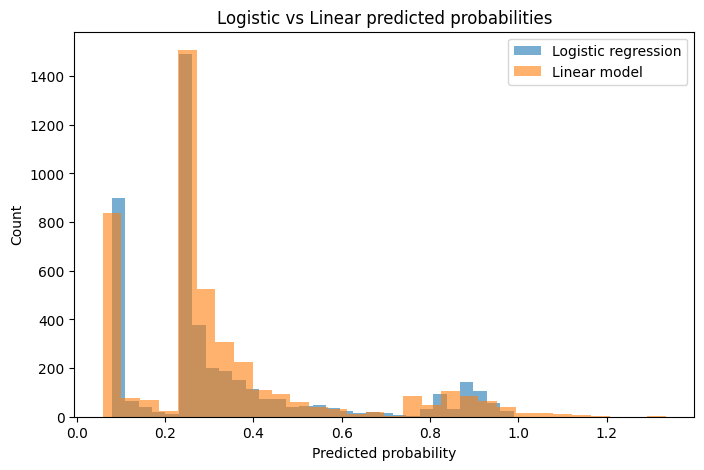


Linear model confusion matrix:
[[2870  133]
 [ 914  507]]

Linear model accuracy:
0.7633363471971067


In [6]:
lin = LinearRegression()
lin.fit(X, y)

df2["linear_prob"] = lin.predict(X)

print("Linear model coefficients:")
for name, coef in zip(X.columns, lin.coef_):
    print(name, coef)

print("\nRange of linear predicted values:")
print(df2["linear_prob"].min(), df2["linear_prob"].max())

plt.figure(figsize=(8,5))
plt.hist(df2["logit_prob"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(df2["linear_prob"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Logistic vs Linear predicted probabilities")
plt.legend()
plt.show()

y_pred_lin = (df2["linear_prob"] >= 0.5).astype(int)

print("\nLinear model confusion matrix:")
print(confusion_matrix(y, y_pred_lin))

print("\nLinear model accuracy:")
print(accuracy_score(y, y_pred_lin))

The linear model produces coefficients with similar directional interpretations as the logistic regression, where being a debtor and older at enrollment increase dropout probability, while being up to date on tuition and having a scholarship decrease it. However, a key issue with the linear model is that its predicted values are not constrained between 0 and 1. In this case, the predicted “probabilities” range from about 0.058 to 1.335, meaning some predictions exceed 1, which is not meaningful for probabilities. The histogram further highlights this difference: logistic regression predictions are properly bounded between 0 and 1, while the linear model produces a wider spread, including invalid values above 1. Although the classification accuracy of the linear model (approximately 0.763) is very similar to that of logistic regression (approximately 0.762), logistic regression is more appropriate because it provides valid probability estimates and a more theoretically sound framework for classification problems. Overall, while both models perform similarly in terms of accuracy, logistic regression is preferable because its predictions are interpretable as probabilities and remain within the correct range.

The students most at risk of dropping out are those who are debtors, not up to date on tuition, not scholarship holders, and older at enrollment, since all of these variables were associated with higher predicted dropout probabilities in the logistic regression model. Among these factors, not being up to date on tuition appears to be the strongest predictor of dropout, as it had the largest negative coefficient and resulted in a large reduction in predicted dropout probability when tuition was up to date. Based on these findings, interventions should focus primarily on financial support and early identification of at-risk students. For example, universities could offer flexible payment plans, emergency financial aid, or targeted outreach to students who fall behind on tuition payments. Expanding access to scholarships or providing financial counseling could also help reduce dropout risk. Additionally, because older students are at higher risk, institutions could provide tailored academic advising, flexible course scheduling, or support services for nontraditional students to help them balance school with other responsibilities.

In [7]:
X_multi = df2[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = df2["Target"]

multi = LogisticRegression(max_iter=5000)
multi.fit(X_multi, y_multi)

y_pred_multi = multi.predict(X_multi)
proba_multi = multi.predict_proba(X_multi)

print("Classes:")
print(multi.classes_)

cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=multi.classes_)
acc_multi = accuracy_score(y_multi, y_pred_multi)

print("\nConfusion matrix:")
print(cm_multi)

print("\nAccuracy:")
print(acc_multi)

print("\nPredicted class counts:")
print(pd.Series(y_pred_multi).value_counts())

proba_df = pd.DataFrame(proba_multi, columns=multi.classes_)

print("\nPredicted probabilities (first few rows):")
print(proba_df.head())

print("\nProbability summary:")
print(proba_df.describe())

Classes:
['Dropout' 'Enrolled' 'Graduate']

Confusion matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

Accuracy:
0.7045660036166366

Predicted class counts:
Graduate    2944
Dropout     1480
Name: count, dtype: int64

Predicted probabilities (first few rows):
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104

Probability summary:
            Dropout     Enrolled     Graduate
count  4.424000e+03  4424.000000  4424.000000
mean   3.212229e-01     0.179474     0.499303
std    2.866920e-01     0.066308     0.287579
min    9.564711e-07     0.000279     0.002135
25%    1.178080e-01     0.140644     0.172735
50%    1.842268e-01     0.176983     0.603104
75%    5.898657e-01     0.212669     0.705209
max    9.601568e-01     0.327752     0.999720


The multinomial logistic regression model predicts three classes: Dropout, Enrolled, and Graduate, and achieves an overall accuracy of approximately 0.705, meaning it correctly classifies about 70.5% of observations. The confusion matrix shows that the model performs reasonably well for the Dropout and Graduate classes, correctly classifying 1054 Dropout cases and 2063 Graduate cases. However, it fails to correctly classify any Enrolled students, as the entire second row of the confusion matrix is misclassified. This is further confirmed by the predicted class counts, which show that the model only predicts Dropout and Graduate, and never predicts Enrolled as the final class. Therefore, the hard classification does not predict every class. However, when examining the predicted probabilities from .predict_proba, the model does assign nonzero probabilities to all three classes, including Enrolled. The summary statistics show that the Enrolled class consistently receives some probability mass, even though it is never the highest probability for any observation. This indicates that while the model recognizes the Enrolled class, it does not consider it the most likely outcome for any case, leading to its absence in the hard predictions. This suggests that the model may struggle to distinguish Enrolled from the other two classes using the given predictors.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("cirrhosis.csv")

cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df2 = df[cols].copy()

print("Shape:", df2.shape)
print("\nColumns:", df2.columns.tolist())

print("\nMissing values:")
print(df2.isna().sum())

print("\nStatus counts:")
print(df2["Status"].value_counts(dropna=False))

print("\nEdema counts:")
print(df2["Edema"].value_counts(dropna=False))

print("\nDrug counts:")
print(df2["Drug"].value_counts(dropna=False))

print("\nStage counts:")
print(df2["Stage"].value_counts(dropna=False))

Shape: (418, 5)

Columns: ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']

Missing values:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Status counts:
Status
C     232
D     161
CL     25
Name: count, dtype: int64

Edema counts:
Edema
N    354
S     44
Y     20
Name: count, dtype: int64

Drug counts:
Drug
D-penicillamine    158
Placebo            154
NaN                106
Name: count, dtype: int64

Stage counts:
Stage
3.0    155
4.0    144
2.0     92
1.0     21
NaN      6
Name: count, dtype: int64


In [9]:
surv = df2[["Bilirubin", "Edema", "Drug", "Status"]].dropna().copy()

surv["survive"] = surv["Status"].isin(["C", "CL"]).astype(int)

X = pd.get_dummies(surv[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y = surv["survive"]

logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

print("Columns used in model:")
print(X.columns.tolist())

print("\nIntercept:")
print(logit.intercept_)

print("\nCoefficients:")
for name, coef in zip(X.columns, logit.coef_[0]):
    print(name, coef)

Columns used in model:
['Bilirubin', 'Edema_S', 'Edema_Y', 'Drug_Placebo']

Intercept:
[1.3798278]

Coefficients:
Bilirubin -0.35142389843544086
Edema_S -0.45067663255235757
Edema_Y -1.6110491833168035
Drug_Placebo 0.23122512449170882


The logistic regression model uses Bilirubin, Edema, and Drug to predict survival status. The coefficient for Drug_Placebo is positive (0.231), which means that being in the placebo group is associated with higher survival probability compared to the baseline group (D-penicillamine). Therefore, the drug does not appear to improve survival; instead, patients receiving D-penicillamine have slightly lower predicted survival probabilities than those receiving placebo. The coefficient for Bilirubin is negative (-0.351), indicating that higher bilirubin levels are associated with lower survival probability. This suggests that patients with worse liver function (higher bilirubin) are less likely to survive. For edema, both coefficients are negative, with Edema_S (-0.451) and Edema_Y (-1.611), meaning that any presence of edema reduces survival probability compared to having no edema. Additionally, the effect is much stronger for Edema_Y, which represents edema despite diuretics, indicating the most severe condition. This shows that survival decreases as edema severity increases.

   Bilirubin             Drug  logit_prob
0       14.5  D-penicillamine    0.004836
1        1.1  D-penicillamine    0.729732
2        1.4  D-penicillamine    0.607582
3        1.8  D-penicillamine    0.573608
4        3.4          Placebo    0.602576


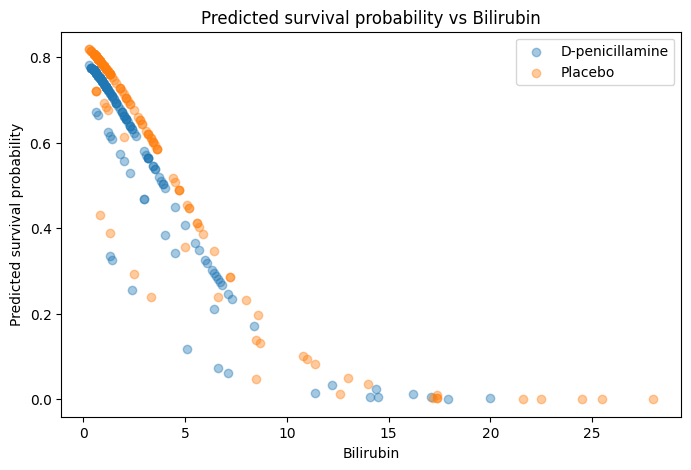


Average change in predicted survival probability for D-penicillamine vs Placebo:
-0.042426639431640066

Effect by bilirubin (largest positive values):
Bilirubin
28.0   -0.000035
22.5   -0.000076
25.5   -0.000132
24.5   -0.000188
21.6   -0.000332
17.9   -0.000381
17.2   -0.000487
20.0   -0.000581
17.4   -0.001050
14.5   -0.001250
Name: delta_drug, dtype: float64


In [10]:
surv["logit_prob"] = logit.predict_proba(X)[:, 1]

print(surv[["Bilirubin", "Drug", "logit_prob"]].head())

plt.figure(figsize=(8,5))

for drug_name in surv["Drug"].unique():
    subset = surv[surv["Drug"] == drug_name]
    plt.scatter(subset["Bilirubin"], subset["logit_prob"], alpha=0.4, label=drug_name)

plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival probability vs Bilirubin")
plt.legend()
plt.show()

X_dpen = X.copy()
X_placebo = X.copy()

if "Drug_Placebo" in X.columns:
    X_dpen["Drug_Placebo"] = 0
    X_placebo["Drug_Placebo"] = 1

p_dpen = logit.predict_proba(X_dpen)[:, 1]
p_placebo = logit.predict_proba(X_placebo)[:, 1]

delta = p_dpen - p_placebo

print("\nAverage change in predicted survival probability for D-penicillamine vs Placebo:")
print(delta.mean())

bilirubin_effect = pd.DataFrame({
    "Bilirubin": surv["Bilirubin"],
    "delta_drug": delta
})

print("\nEffect by bilirubin (largest positive values):")
print(bilirubin_effect.groupby("Bilirubin")["delta_drug"].mean().sort_values(ascending=False).head(10))

The predicted survival probability decreases as bilirubin levels increase, indicating that patients with higher bilirubin levels have lower chances of survival. This pattern is consistent across both treatment groups, showing a clear negative relationship between bilirubin and survival probability. Comparing the two drug groups, patients in the placebo group generally have slightly higher predicted survival probabilities than those receiving D-penicillamine at the same bilirubin levels. This suggests that the drug does not improve survival and may even be associated with a small decrease in survival probability. The effect of the drug appears to be relatively consistent across different bilirubin levels, with no clear range where D-penicillamine provides a survival advantage. The average change in predicted survival probability for patients receiving D-penicillamine compared to placebo is approximately -0.042, meaning that, on average, the drug reduces survival probability by about 4.2 percentage points. Overall, the strongest factor influencing survival in this model is bilirubin level, while the effect of the drug is relatively small and slightly negative across all values.

In [11]:
y_pred_logit = logit.predict(X)

cm_logit = confusion_matrix(y, y_pred_logit)
acc_logit = accuracy_score(y, y_pred_logit)

print("Confusion matrix:")
print(cm_logit)

print("\nAccuracy:")
print(acc_logit)

Confusion matrix:
[[ 59  66]
 [ 16 171]]

Accuracy:
0.7371794871794872


The confusion matrix shows that the model correctly classified 171 patients who survived and 59 patients who did not survive. However, it incorrectly classified 66 patients who did not survive as survivors (false positives) and 16 patients who survived as non-survivors (false negatives). The overall accuracy of the model is approximately 0.737, meaning it correctly classifies about 73.7% of patients. This indicates that the model performs reasonably well overall, particularly in identifying patients who survive, as shown by the relatively high number of true positives. However, it is less accurate in identifying patients who do not survive, as evidenced by the higher number of false positives. This suggests the model tends to overpredict survival in some cases.

Linear model coefficients:
Bilirubin -0.03906759515324219
Edema_S -0.11888047945617125
Edema_Y -0.3483070810844937
Drug_Placebo 0.05063990691912469

Range of linear predicted values:
-0.4417396683935991 0.7738680250928711


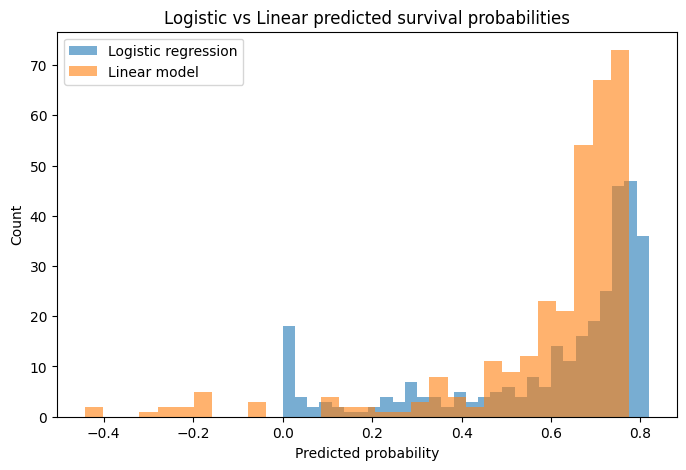


Linear model confusion matrix:
[[ 47  78]
 [  9 178]]

Linear model accuracy:
0.7211538461538461


In [12]:
lin = LinearRegression()
lin.fit(X, y)

surv["linear_prob"] = lin.predict(X)

print("Linear model coefficients:")
for name, coef in zip(X.columns, lin.coef_):
    print(name, coef)

print("\nRange of linear predicted values:")
print(surv["linear_prob"].min(), surv["linear_prob"].max())

plt.figure(figsize=(8,5))
plt.hist(surv["logit_prob"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(surv["linear_prob"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Logistic vs Linear predicted survival probabilities")
plt.legend()
plt.show()

y_pred_lin = (surv["linear_prob"] >= 0.5).astype(int)

print("\nLinear model confusion matrix:")
print(confusion_matrix(y, y_pred_lin))

print("\nLinear model accuracy:")
print(accuracy_score(y, y_pred_lin))

The linear model produces coefficients that are consistent in direction with the logistic regression, where higher bilirubin levels and more severe edema decrease survival probability, while being in the placebo group slightly increases survival probability. However, a major limitation of the linear model is that its predicted values are not constrained between 0 and 1. In this case, the predicted “probabilities” range from approximately -0.442 to 0.774, meaning some predictions are negative, which is not meaningful for probabilities. The histogram highlights this issue further, as the logistic regression predictions are properly bounded between 0 and 1, while the linear model produces a wider distribution that includes invalid negative values. In terms of classification performance, the linear model has an accuracy of approximately 0.721, which is slightly lower than the logistic regression accuracy of approximately 0.737. Overall, logistic regression performs better both theoretically and practically. It provides valid probability estimates and slightly higher accuracy, making it the more appropriate model for predicting survival in this case.

In [13]:
stage_df = df2[["Stage", "Edema", "Bilirubin"]].dropna().copy()

stage_df["Stage"] = stage_df["Stage"].astype(int)

X_stage = pd.get_dummies(stage_df[["Edema", "Bilirubin"]], drop_first=True)
y_stage = stage_df["Stage"]

stage_model = LogisticRegression(max_iter=5000)
stage_model.fit(X_stage, y_stage)

y_pred_stage = stage_model.predict(X_stage)
proba_stage = stage_model.predict_proba(X_stage)

print("Classes:")
print(stage_model.classes_)

cm_stage = confusion_matrix(y_stage, y_pred_stage, labels=stage_model.classes_)
acc_stage = accuracy_score(y_stage, y_pred_stage)

print("\nConfusion matrix:")
print(cm_stage)

print("\nAccuracy:")
print(acc_stage)

print("\nPredicted class counts:")
print(pd.Series(y_pred_stage).value_counts())

proba_stage_df = pd.DataFrame(proba_stage, columns=stage_model.classes_)

print("\nPredicted probabilities (first few rows):")
print(proba_stage_df.head())

print("\nProbability summary:")
print(proba_stage_df.describe())

Classes:
[1 2 3 4]

Confusion matrix:
[[  0   0  20   1]
 [  0   0  82  10]
 [  0   0 130  25]
 [  0   0  93  51]]

Accuracy:
0.4393203883495146

Predicted class counts:
3    325
4     87
Name: count, dtype: int64

Predicted probabilities (first few rows):
          1         2         3         4
0  0.000469  0.051110  0.137332  0.811088
1  0.068675  0.255046  0.397580  0.278699
2  0.039844  0.139560  0.340088  0.480508
3  0.035217  0.137518  0.338843  0.488422
4  0.035049  0.243194  0.404019  0.317738

Probability summary:
                1           2           3           4
count  412.000000  412.000000  412.000000  412.000000
mean     0.050965    0.223280    0.376210    0.349545
std      0.026546    0.056294    0.056868    0.128803
min      0.000006    0.029500    0.098909    0.264236
25%      0.033018    0.225035    0.393821    0.273338
50%      0.058634    0.252837    0.396439    0.288347
75%      0.074798    0.256037    0.400384    0.357730
max      0.086112    0.257315    0.40

The logistic regression model predicts Stage values from 1 to 4 using Edema and Bilirubin, and achieves an overall accuracy of approximately 0.439, indicating relatively poor classification performance. The confusion matrix shows that the model correctly classifies some cases in Stage 3 and Stage 4, but completely fails to correctly classify any observations in Stage 1 or Stage 2. This is reflected in the predicted class counts, where the model only predicts Stage 3 and Stage 4, and never predicts Stage 1 or Stage 2 as the final class. This indicates that the hard classification does not predict every class, as it excludes the lower stages entirely. However, when examining the predicted probabilities from .predict_proba, the model does assign nonzero probabilities to all four stages. The probability summary shows that Stages 1 and 2 receive small but nonzero probability values across observations, even though they are never the most likely class. Overall, this suggests that while the model recognizes the existence of all four stages, it struggles to distinguish between them using the given predictors. In particular, it tends to favor predicting intermediate and higher stages (especially Stage 3), indicating that Edema and Bilirubin alone may not provide enough information to accurately classify all disease stages.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

### 4.1

The coefficients in a logistic regression are the weights on the predictors in the model’s linear predictor, or latent variable. Unlike ordinary linear regression, these coefficients do not represent the direct change in predicted probability for a one-unit increase in a predictor. Instead, each coefficient represents the change in the log-odds of the outcome for a one-unit increase in that predictor, holding all other variables constant. A positive coefficient means the predictor increases the log-odds, and therefore increases the probability of the outcome, while a negative coefficient means it decreases the log-odds and lowers the probability of the outcome. If we exponentiate a coefficient, $e^{b_k}$, we get the multiplicative change in the odds for a one-unit increase in $x_k$.

The coefficients represent the change in the log-odds of the outcome:

$$
\log\left(\frac{\hat{p}}{1-\hat{p}}\right)=b_0+\sum_{k=1}^{K} b_k x_k
$$

Exponentiating the coefficient gives the change in the odds:

$$
e^{b_k}
$$

### 4.2

For the linear model, the prediction is

$$
\hat{y}=b\cdot x=b_0+\sum_{k=1}^{K} b_k x_k
$$

The derivative of the prediction with respect to the $k$-th feature is

$$
\frac{\partial \hat{y}}{\partial x_k}=b_k
$$

This means that for a one-unit increase in $x_k$, the prediction changes by exactly $b_k$, holding all other predictors constant. The effect is constant and does not depend on the value of $x$.

### 4.3

For the logistic model, the prediction is

$$
\hat{p}=\frac{e^{b\cdot x}}{1+e^{b\cdot x}}
$$

Using the chain rule, the derivative of the prediction with respect to the $k$-th feature is

$$
\frac{\partial \hat{p}}{\partial x_k}=b_k \hat{p}(1-\hat{p})
$$

Unlike the linear model, this effect is not constant. It depends on the value of $\hat{p}$, so as $x$ changes, the effect of $x_k$ on the predicted probability also changes. This is similar to the linear model because the coefficient $b_k$ still controls the direction of the effect, but it is different because the actual size of the effect is scaled by $\hat{p}(1-\hat{p})$.

The term $\hat{p}(1-\hat{p})$ is largest when $\hat{p}=0.5$, so

$$
\hat{p}(1-\hat{p}) \leq \frac{1}{4}
$$

and therefore the largest marginal effect is

$$
\frac{\partial \hat{p}}{\partial x_k} \leq \frac{b_k}{4}
$$

So $\frac{b_k}{4}$ is a good approximation of how a one-unit increase in $x_k$ affects the predicted probability when $\hat{p}$ is close to $0.5$.

Alternatively, we can write the model in log-odds form:

$$
\log\left(\frac{\hat{p}}{1-\hat{p}}\right)=b\cdot x
$$

A one-unit increase in $x_k$ changes the log-odds ratio by exactly

$$
b_k
$$